In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

# Configuración de estilo para los gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar el dataset
# Nota: El archivo tiene un nombre largo, asegúrate de que coincida con el tuyo
archivo = 'dataset_empresarial_outliers.xlsx'
df = pd.read_excel(archivo)

# Vista previa de los datos
print("Primeras 5 filas del dataset:")
display(df.head())

# Información general para ver tipos de datos y nulos
print("\nInformación del dataset:")
df.info()

Primeras 5 filas del dataset:


,ingresos,costes,satisfaccion,empleados,departamento,region,canal
0,29138,8677,4.162521,35,Finanzas,Islas,online
1,26082,11077,4.025476,9,IT,Oeste,online
2,20710,8972,4.381085,29,Marketing,Oeste,online
3,20456,12536,3.918395,17,Finanzas,Norte,partners
4,23734,14439,4.692548,45,IT,Oeste,tienda



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ingresos      409 non-null    int64  
 1   costes        409 non-null    int64  
 2   satisfaccion  409 non-null    float64
 3   empleados     409 non-null    int64  
 4   departamento  409 non-null    object 
 5   region        409 non-null    object 
 6   canal         409 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 22.5+ KB


# 1. Análisis Exploratorio (EDA) - Estadísticas Descriptivas
Aquí analizamos las estadísticas básicas (media, desviación estándar, mínimos y máximos). Esto nos ayuda a detectar anomalías evidentes, como ingresos negativos o valores de satisfacción fuera de la escala 1-5.

In [3]:
# Estadísticas descriptivas de las variables numéricas
print("Estadísticas Descriptivas:")
display(df.describe())

# Verificamos valores únicos en satisfacción (debe ser escala 1-5)
print("\nValores únicos en 'satisfaccion' (debería ser 1-5):")
print(df['satisfaccion'].unique())

Estadísticas Descriptivas:


,ingresos,costes,satisfaccion,empleados
count,409.000000,409.000000,409.000000,409.000000
mean,25400.039120,11696.699267,3.850957,28.515892
std,7855.275835,3614.124107,0.541404,18.678927
min,5000.000000,8002.000000,0.100000,0.000000
25%,22333.000000,9871.000000,3.425137,17.000000
50%,24816.000000,11502.000000,3.837568,27.000000
75%,27729.000000,13000.000000,4.279791,39.000000
max,150000.000000,60000.000000,6.000000,300.000000



Valores únicos en 'satisfaccion' (debería ser 1-5):
[4.16252084 4.02547585 4.38108457 3.91839511 4.69254828 4.0722086
 3.05829517 4.37721044 3.80398545 4.17862831 3.40837396 3.52969792
 3.49416336 4.06039564 3.61802623 3.733975   4.13769729 4.04798513
 3.56715085 3.7104784  3.27581695 3.41077854 3.58672644 4.11058441
 4.40212145 3.41671612 3.13114515 4.48676574 3.53508528 3.09783829
 3.47865515 3.04217823 4.59164722 3.08813425 3.88486057 3.65985407
 3.20259514 4.29582989 3.01197742 4.3150387  3.24589288 3.84556304
 4.30781266 3.48748349 4.1696118  3.22114529 3.24451982 4.43166543
 3.38552094 3.09291026 4.39608992 3.74594736 3.39458545 3.84291075
 3.24225354 3.24852377 3.8396363  4.4741047  3.18659112 4.31671738
 3.92925995 4.17661529 3.45363662 4.7443098  3.32919459 3.50908356
 3.06849982 3.75560637 4.4339021  4.07497478 3.7921688  3.35910488
 4.43804202 3.17861011 4.16728805 3.76395435 4.46401196 3.33327412
 3.71142687 4.26790113 4.66755907 3.0146381  3.12373437 3.63152706
 3.4643218

# 1. Análisis Exploratorio (EDA) - Visualización (Histogramas y Boxplots)
Generamos gráficos para entender la distribución de las variables.
* **Histogramas:** Para ver la forma de la distribución (normal, sesgada, etc.).
* **Boxplots:** Para identificar visualmente los puntos atípicos (outliers).

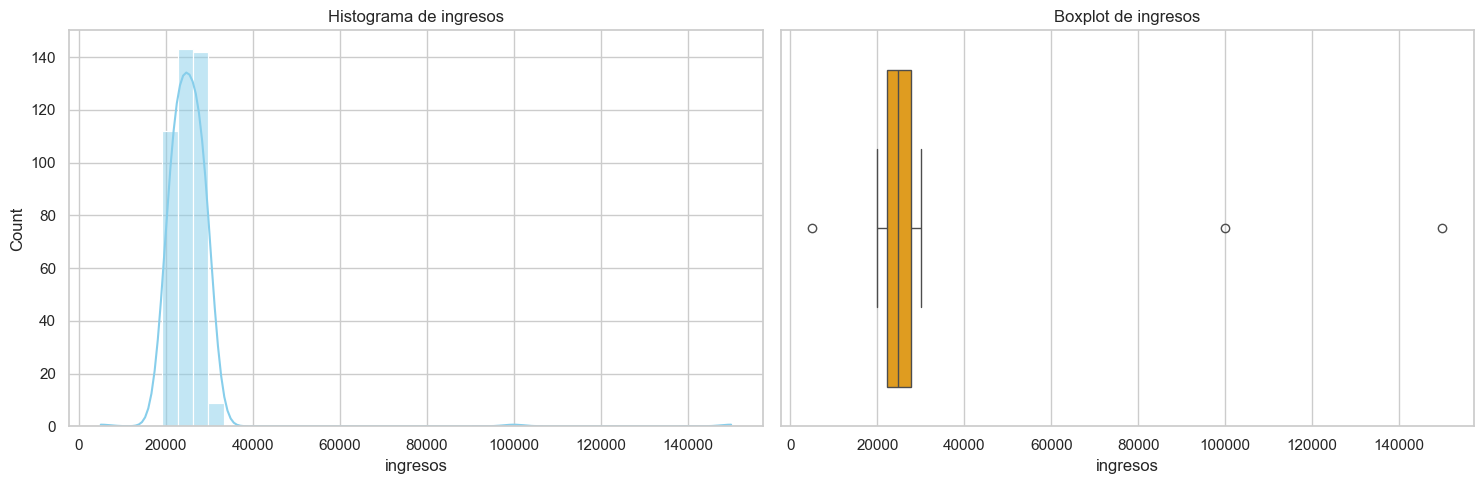

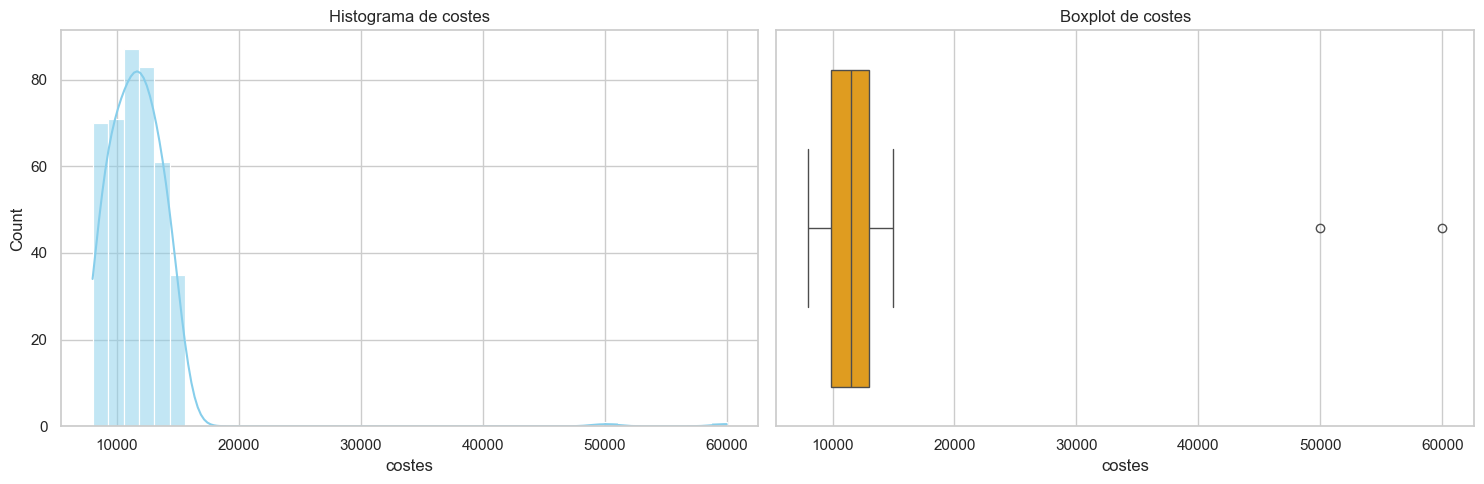

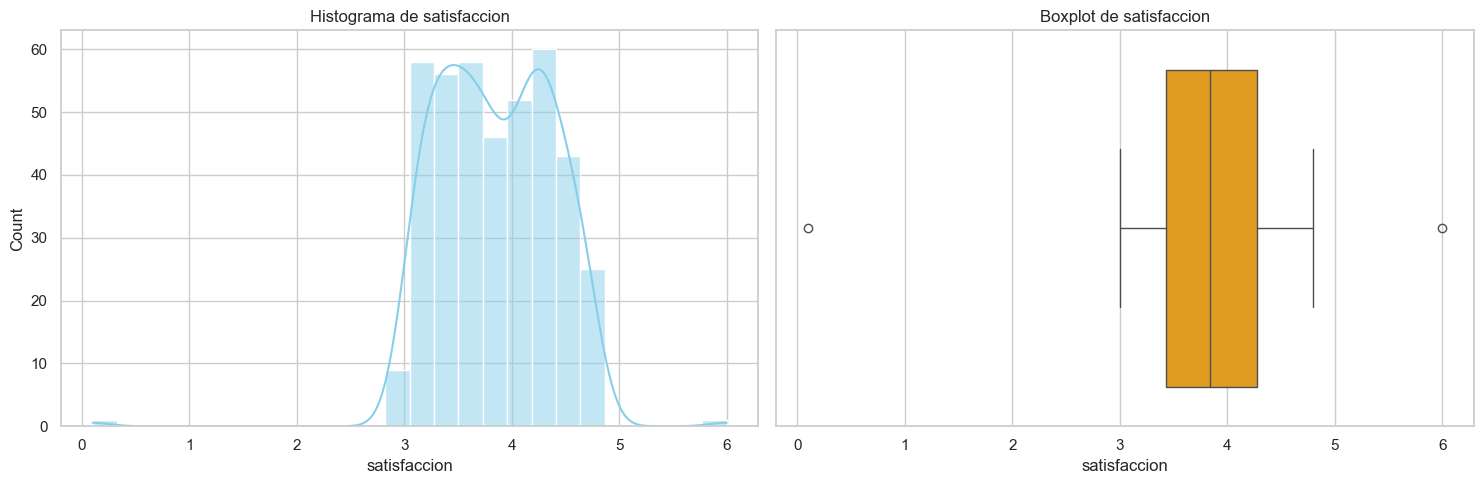

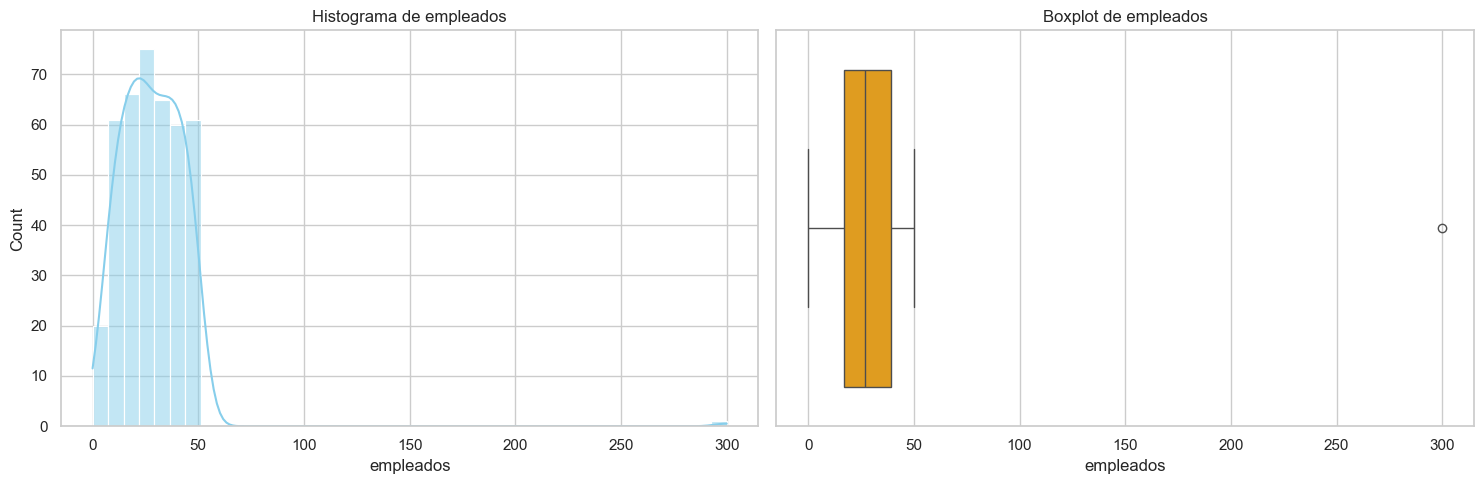

In [4]:
# Definimos las columnas numéricas de interés
cols_numericas = ['ingresos', 'costes', 'satisfaccion', 'empleados']

# Creamos histogramas y boxplots para cada variable
for col in cols_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histograma de {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='orange')
    axes[1].set_title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

# 2. Identificación de Outliers - Método Z-Score
El Z-Score mide cuántas desviaciones estándar se aleja un dato de la media. Un umbral común es **3**. Si el valor absoluto del Z-Score es mayor a 3, se considera un outlier.

In [5]:
# Método 1: Z-Score
print("--- Detección por Z-Score ---")
outliers_zscore = {}

for col in cols_numericas:
    # Calculamos Z-score
    z_scores = np.abs(stats.zscore(df[col]))
    # Umbral típico es 3
    mask = z_scores > 3
    outliers_zscore[col] = df[mask]
    print(f"Outliers detectados en {col} (Z-Score > 3): {mask.sum()}")

# Ejemplo: Ver algunos outliers de ingresos por Z-Score
display(outliers_zscore['ingresos'].head())

--- Detección por Z-Score ---
Outliers detectados en ingresos (Z-Score > 3): 2
Outliers detectados en costes (Z-Score > 3): 2
Outliers detectados en satisfaccion (Z-Score > 3): 2
Outliers detectados en empleados (Z-Score > 3): 1


,ingresos,costes,satisfaccion,empleados,departamento,region,canal
400,100000,12517,3.167049,18,Operaciones,Islas,partners
401,150000,12974,3.931346,27,IT,Norte,partners


# 2. Identificación de Outliers - Método IQR (Rango Intercuartílico)
Este método utiliza los cuartiles (Q1 y Q3). Es más robusto que el Z-Score porque no depende de la media ni de la desviación estándar (que se ven afectadas por los propios outliers). Se define como outlier cualquier valor fuera del rango: `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.

In [6]:
# Método 2: IQR (Interquartile Range)
print("--- Detección por IQR ---")
outliers_iqr = {}

for col in cols_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_iqr[col] = df[mask]
    
    print(f"Outliers detectados en {col} (IQR): {mask.sum()}")
    print(f"   Límites {col}: < {lower_bound:.2f} | > {upper_bound:.2f}")

# Ejemplo: Ver algunos outliers de empleados por IQR
display(outliers_iqr['empleados'].head())

--- Detección por IQR ---
Outliers detectados en ingresos (IQR): 3
   Límites ingresos: < 14239.00 | > 35823.00
Outliers detectados en costes (IQR): 2
   Límites costes: < 5177.50 | > 17693.50
Outliers detectados en satisfaccion (IQR): 2
   Límites satisfaccion: < 2.14 | > 5.56
Outliers detectados en empleados (IQR): 1
   Límites empleados: < -16.00 | > 72.00


,ingresos,costes,satisfaccion,empleados,departamento,region,canal
408,24937,10548,4.378294,300,Marketing,Este,online


# 2. Identificación de Outliers - Método MAD y Método Extra (Isolation Forest)
* **MAD (Median Absolute Deviation):** Muy robusto. Usamos un Z-Score modificado basado en la mediana.
* **Isolation Forest (Extra):** Un algoritmo de Machine Learning no supervisado que aísla anomalías basándose en árboles de decisión. Es útil para detectar patrones raros multivariantes.

In [7]:
# Método 3: MAD (Median Absolute Deviation) - Usando Z-Score Modificado
# Si el Z-score modificado > 3.5, se suele considerar outlier
print("--- Detección por MAD (Z-Score Modificado) ---")

def is_outlier_mad(points, thresh=3.5):
    median = np.median(points)
    diff = np.abs(points - median)
    med_abs_deviation = np.median(diff)
    
    # El 0.6745 es la constante para consistencia con la desviación estándar normal
    modified_z_score = 0.6745 * diff / med_abs_deviation
    return modified_z_score > thresh

outliers_mad = {}
for col in cols_numericas:
    mask = is_outlier_mad(df[col])
    outliers_mad[col] = df[mask]
    print(f"Outliers detectados en {col} (MAD): {mask.sum()}")


# Método 4 (Extra): Isolation Forest (Machine Learning)
print("\n--- Método Extra: Isolation Forest ---")
# Isolation Forest detecta anomalías basándose en qué tan fácil es aislar un punto
iso = IsolationForest(contamination=0.05, random_state=42) # Asumimos un 5% de contaminación
df['anomaly_score'] = iso.fit_predict(df[cols_numericas])

# Los outliers se marcan como -1
n_outliers_iso = (df['anomaly_score'] == -1).sum()
print(f"Total de filas detectadas como anomalías por Isolation Forest: {n_outliers_iso}")

--- Detección por MAD (Z-Score Modificado) ---
Outliers detectados en ingresos (MAD): 3
Outliers detectados en costes (MAD): 2
Outliers detectados en satisfaccion (MAD): 1
Outliers detectados en empleados (MAD): 1

--- Método Extra: Isolation Forest ---
Total de filas detectadas como anomalías por Isolation Forest: 21


# 3. Comparación entre Métodos
Creamos una tabla resumen para ver cuántos outliers detecta cada método por variable. Esto nos permite debatir cuál es más sensible o adecuado.

In [11]:
# Crear un resumen comparativo
comparacion = {
    'Variable': [],
    'Z-Score (N)': [],
    'IQR (N)': [],
    'MAD (N)': []
}

for col in cols_numericas:
    comparacion['Variable'].append(col)
    comparacion['Z-Score (N)'].append(len(outliers_zscore[col]))
    comparacion['IQR (N)'].append(len(outliers_iqr[col]))
    comparacion['MAD (N)'].append(len(outliers_mad[col]))

df_comparacion = pd.DataFrame(comparacion)
print("Comparación de número de outliers detectados por método:")
display(df_comparacion)

# Comentario analítico
print("""
OBSERVACIONES:
1. Z-Score asume distribución normal. Si los datos están muy sesgados, puede fallar.
2. IQR es robusto y suele detectar más outliers leves.
3. MAD es el más robusto ante valores extremos muy grandes.
4. Isolation Forest detecta combinaciones multivariantes anómalas (filas raras en conjunto).
""")

Comparación de número de outliers detectados por método:


,Variable,Z-Score (N),IQR (N),MAD (N)
0,ingresos,2,3,3
1,costes,2,2,2
2,satisfaccion,2,2,1
3,empleados,1,1,1



OBSERVACIONES:
1. Z-Score asume distribución normal. Si los datos están muy sesgados, puede fallar.
2. IQR es robusto y suele detectar más outliers leves.
3. MAD es el más robusto ante valores extremos muy grandes.
4. Isolation Forest detecta combinaciones multivariantes anómalas (filas raras en conjunto).



# 4. Tratamiento de Datos (Limpieza e Imputación)
Aplicamos reglas de negocio para tratar los outliers detectados:
1.  **Ingresos Negativos:** Se consideran errores imposibles -> *Eliminar*.
2.  **Satisfacción fuera de rango (1-5):** Error de escala -> *Imputar con la Mediana*.
3.  **Costes Extremos:** Valores posibles pero muy altos -> *Capping (Winsorizing)* al percentil 95.

In [15]:
# Hacemos una copia para tratar los datos
df_clean = df.copy()

print("--- Tratamiento de Datos ---")

# CASO 1: Ingresos negativos (Eliminar)
# Aunque sean 0 en este archivo, dejamos la lógica por si el dataset cambia en el futuro
mask_ingresos_neg = df_clean['ingresos'] < 0
print(f"Eliminando {mask_ingresos_neg.sum()} registros con ingresos negativos.")
df_clean = df_clean[~mask_ingresos_neg]

# CASO 2: Satisfacción fuera de rango (Imputar Mediana)
median_sat = df_clean['satisfaccion'].median()
mask_sat_bad = (df_clean['satisfaccion'] < 1) | (df_clean['satisfaccion'] > 5)
print(f"Imputando {mask_sat_bad.sum()} valores de satisfacción fuera de rango con la mediana ({median_sat:.2f}).")
df_clean.loc[mask_sat_bad, 'satisfaccion'] = median_sat

# CASO 3: Costes Extremos (Capping al percentil 95)
upper_limit = df_clean['costes'].quantile(0.95)
mask_costes_high = df_clean['costes'] > upper_limit

print(f"Topeando {mask_costes_high.sum()} valores de costes al percentil 95 ({upper_limit:.2f}).")

# CORRECCIÓN IMPORTANTE: Convertimos a float para evitar el error y usamos print para ver la tabla
df_clean['costes'] = df_clean['costes'].astype(float)
df_clean.loc[mask_costes_high, 'costes'] = upper_limit

# Verificación final
print("\nEstadísticas después de la limpieza:")
# Usamos print() en lugar de display() para asegurar que salga el texto
print(df_clean[cols_numericas].describe())

--- Tratamiento de Datos ---
Eliminando 0 registros con ingresos negativos.
Imputando 2 valores de satisfacción fuera de rango con la mediana (3.84).
Topeando 21 valores de costes al percentil 95 (14633.00).

Estadísticas después de la limpieza:
            ingresos        costes  satisfaccion   empleados
count     409.000000    409.000000    409.000000  409.000000
mean    25400.039120  11491.078240      3.854808   28.515892
std      7855.275835   1922.655371      0.497293   18.678927
min      5000.000000   8002.000000      3.002063    0.000000
25%     22333.000000   9871.000000      3.429704   17.000000
50%     24816.000000  11502.000000      3.837568   27.000000
75%     27729.000000  13000.000000      4.279258   39.000000
max    150000.000000  14633.000000      4.795058  300.000000


# Visualización Final (Antes vs Después)
Comparamos visualmente cómo ha cambiado la distribución de la variable 'costes' tras aplicar el tratamiento de "Capping".

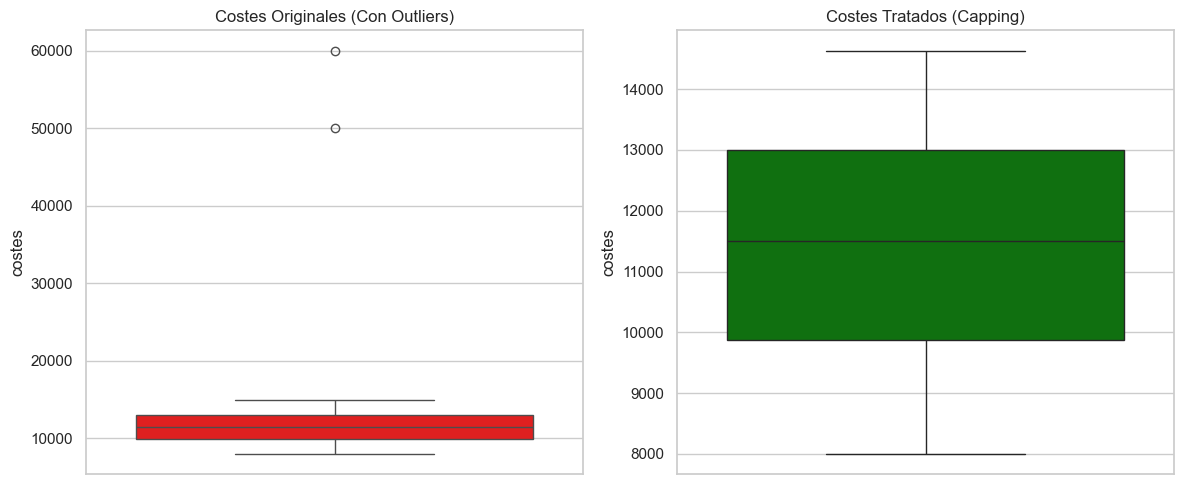

In [10]:
# Comparación visual final de la variable 'costes' antes y después
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['costes'], ax=axes[0], color='red')
axes[0].set_title('Costes Originales (Con Outliers)')

sns.boxplot(y=df_clean['costes'], ax=axes[1], color='green')
axes[1].set_title('Costes Tratados (Capping)')

plt.tight_layout()
plt.show()